# Part 2: Stock Price Prediction Using Time Series Forecasting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [4]:
df = pd.read_csv("Apple.csv")
df.head()

,Unnamed: 0,Date,Open,High,Low,Close,Volume,OpenInt,Stock
0,0,1984-09-07,0.42388,0.42902,0.41874,0.42388,23220030,0,AAPL
1,1,1984-09-10,0.42388,0.42516,0.41366,0.42134,18022532,0,AAPL
2,2,1984-09-11,0.42516,0.43668,0.42516,0.42902,42498199,0,AAPL
3,3,1984-09-12,0.42902,0.43157,0.41618,0.41618,37125801,0,AAPL
4,4,1984-09-13,0.43927,0.44052,0.43927,0.43927,57822062,0,AAPL


In [5]:
df = df[['Date','Open','Close','Volume']]

In [6]:
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
df.set_index('Date', inplace=True)

In [8]:
df = df.dropna()

## Exploratory Data Analysis (EDA)

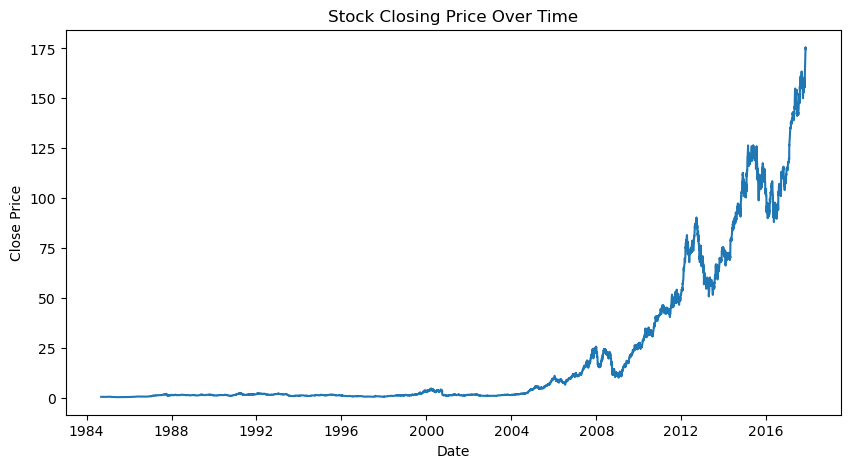

In [9]:
plt.figure(figsize=(10,5))
plt.plot(df['Close'])
plt.title("Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

### Observations
- The closing stock price shows a clear **long-term upward trend** over the years.
- Early years show **low prices with relatively stable movements**.
- From around **2008 onwards, the stock price increases rapidly**, indicating strong growth.
- There are **periodic fluctuations and sharp drops**, representing market volatility.
- Overall, the time series indicates **growth with short-term noise**, which is typical for stock market data.

In [10]:
df['Close_lag1'] = df['Close'].shift(1)

In [11]:
df['MA7'] = df['Close'].rolling(window=7).mean()

In [12]:
df['MA30'] = df['Close'].rolling(window=30).mean()

In [13]:
train_size = int(len(df)*0.8)
train = df['Close'][:train_size]
test = df['Close'][train_size:]

In [14]:
model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

C:\Users\jaina\Downloads\anacondaapp\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\jaina\Downloads\anacondaapp\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\jaina\Downloads\anacondaapp\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [15]:
predictions = model_fit.forecast(steps=len(test))

C:\Users\jaina\Downloads\anacondaapp\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\jaina\Downloads\anacondaapp\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [16]:
mae = mean_absolute_error(test, predictions)

In [17]:
rmse = np.sqrt(mean_squared_error(test, predictions))

In [18]:
mape = np.mean(np.abs((test - predictions) / test)) * 100

C:\Users\jaina\AppData\Local\Temp\ipykernel_27104\460553796.py:1: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  mape = np.mean(np.abs((test - predictions) / test)) * 100


In [19]:
print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 47.00335820786
RMSE: 56.43074978105474
MAPE: nan


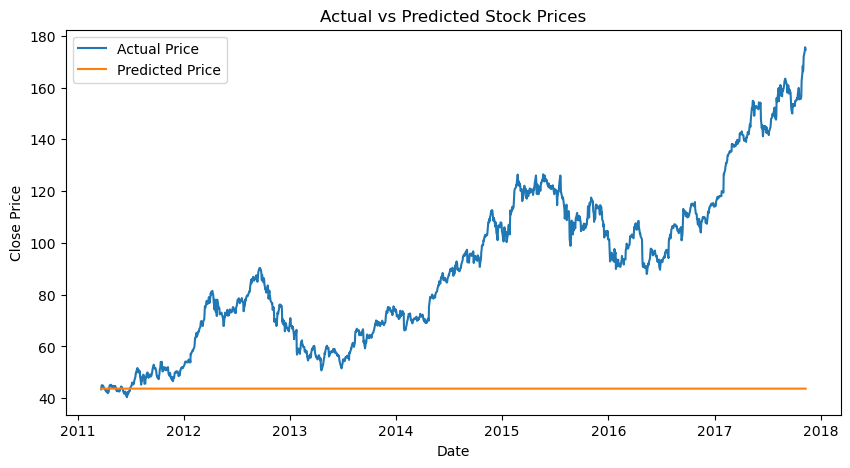

In [20]:
plt.figure(figsize=(10,5))
plt.plot(test.index, test, label="Actual Price")
plt.plot(test.index, predictions, label="Predicted Price")
plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()

### Observations
- The blue line represents the **actual stock closing prices**, which show significant fluctuations and an overall upward trend.
- The orange line represents the **predicted prices from the model**.
- The predicted values appear **almost constant**, indicating that the model failed to capture the changing trend in stock prices.
- This suggests that the **ARIMA parameters or model configuration may need tuning** for better forecasting performance.
- Overall, the model currently **does not fit the real data well**, highlighting the importance of parameter optimization.

C:\Users\jaina\Downloads\anacondaapp\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\jaina\Downloads\anacondaapp\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


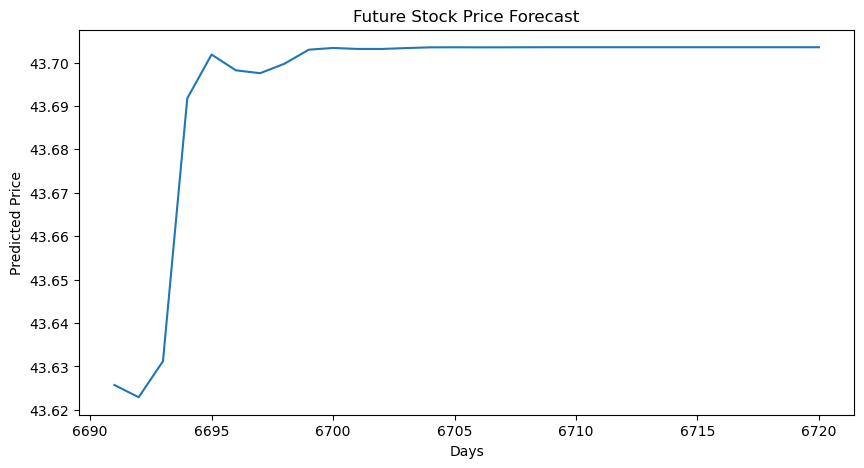

In [21]:
forecast = model_fit.forecast(steps=30)
plt.figure(figsize=(10,5))
plt.plot(forecast)
plt.title("Future Stock Price Forecast")
plt.xlabel("Days")
plt.ylabel("Predicted Price")
plt.show()

### Observations
- The forecast shows **very small changes in predicted prices over future days**.
- The model predicts prices stabilizing around **~43.70**, indicating a nearly constant forecast.
- This suggests the model expects **minimal short-term variation** in stock prices.
- The prediction curve becomes **almost flat**, which is common when the model detects no strong trend in the immediate future.
- Overall, the forecast indicates **price stability rather than significant growth or decline**.